In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.impute import SimpleImputer
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

# Install missing packages if not available
try:
    from xgboost import XGBClassifier
except ImportError:
    print("XGBoost not installed. Install with: pip install xgboost")
    XGBClassifier = None

try:
    from lightgbm import LGBMClassifier
except ImportError:
    print("LightGBM not installed. Install with: pip install lightgbm")
    LGBMClassifier = None

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    precision_score,
    recall_score,
    balanced_accuracy_score,
    matthews_corrcoef,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)
from scipy.stats import f_oneway
import statsmodels.api as sm
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.outliers_influence import variance_inflation_factor

# To install the missing packages, run these commands in a new cell:
# !pip install xgboost
# !pip install lightgbm

In [2]:
!pip install xgboost

In [3]:
!pip install lightgbm

In [ ]:
# Step - 1: Load DataSet

Data = pd.read_csv("recs_cleaned_for_analysis.csv")

print("Shape of dataset:", Data.shape)
display(Data.head())
print(Data.info())

Shape of dataset: (18496, 14)


,DOEID,REGIONC,TYPEHUQ,YEARMADERANGE,TOTSQFT_EN,WALLTYPE,ROOFTYPE,ADQINSUL,HHSEX,HHAGE,EMPLOYHH,MONEYPY,KWH,NWEIGHT
0,100001,WEST,2,4,2100,1,5,2,1,65,3,13,12521.48,3284.103668
1,100002,SOUTH,5,5,590,1,-2,2,1,79,3,6,5243.05,9007.387471
2,100003,WEST,5,3,900,1,-2,2,2,82,3,11,2387.64,5669.002142
3,100004,SOUTH,2,5,2100,3,5,2,2,70,3,10,9275.07,5294.239003
4,100005,NORTHEAST,5,3,800,7,-2,2,2,30,1,16,5869.70,9935.465114


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18496 entries, 0 to 18495
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   DOEID          18496 non-null  int64  
 1   REGIONC        18496 non-null  object 
 2   TYPEHUQ        18496 non-null  int64  
 3   YEARMADERANGE  18496 non-null  int64  
 4   TOTSQFT_EN     18496 non-null  int64  
 5   WALLTYPE       18496 non-null  int64  
 6   ROOFTYPE       18496 non-null  int64  
 7   ADQINSUL       18496 non-null  int64  
 8   HHSEX          18496 non-null  int64  
 9   HHAGE          18496 non-null  int64  
 10  EMPLOYHH       18496 non-null  int64  
 11  MONEYPY        18496 non-null  int64  
 12  KWH            18496 non-null  float64
 13  NWEIGHT        18496 non-null  float64
dtypes: float64(2), int64(11), object(1)
memory usage: 2.0+ MB
None


In [5]:
#Step - 2: Select numeric features and drop ID-like fields

numeric_cols = Data.select_dtypes(include=[np.number]).columns.tolist()

id_like = [c for c in numeric_cols if ("id" in c.lower()) or ("doeid" in c.lower())]
features = [c for c in numeric_cols if c not in id_like]

print("ID-like columns removed:", id_like)
print("Number of features used:", len(features))
print("Features used:", features)

ID-like columns removed: ['DOEID']
Number of features used: 12
Features used: ['TYPEHUQ', 'YEARMADERANGE', 'TOTSQFT_EN', 'WALLTYPE', 'ROOFTYPE', 'ADQINSUL', 'HHSEX', 'HHAGE', 'EMPLOYHH', 'MONEYPY', 'KWH', 'NWEIGHT']


In [6]:
# Step 3: Use KWH only for consumption-based clustering

Feature = Data[["KWH"]].copy()

# Optional but recommended: remove missing/invalid KWH
Feature = Feature.replace([np.inf, -np.inf], np.nan)

imputer = SimpleImputer(strategy="median")
Feature_imputed = imputer.fit_transform(Feature)

In [7]:
# Step 4: Scale features

scaler = StandardScaler()
Feature_scaled = scaler.fit_transform(Feature_imputed)

print("Scaled feature matrix shape:", Feature_scaled.shape)

Scaled feature matrix shape: (18496, 1)


In [8]:
# Step 5: Choose number of clusters K via silhouette

sil_scores = {}
for k in range(2, 8):
    kmeans_tmp = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_tmp = kmeans_tmp.fit_predict(Feature_scaled)
    sil = silhouette_score(Feature_scaled, labels_tmp)
    sil_scores[k] = sil

for k, s in sil_scores.items():
    print(f"K = {k}: silhouette = {s:.4f}")

best_k = max(sil_scores, key=sil_scores.get)
print("Best K selected:", best_k)

K = 2: silhouette = 0.6201
K = 3: silhouette = 0.5695
K = 4: silhouette = 0.5535
K = 5: silhouette = 0.5422
K = 6: silhouette = 0.5431
K = 7: silhouette = 0.5340
Best K selected: 2


cluster
0    13749
1     4747
Name: count, dtype: int64


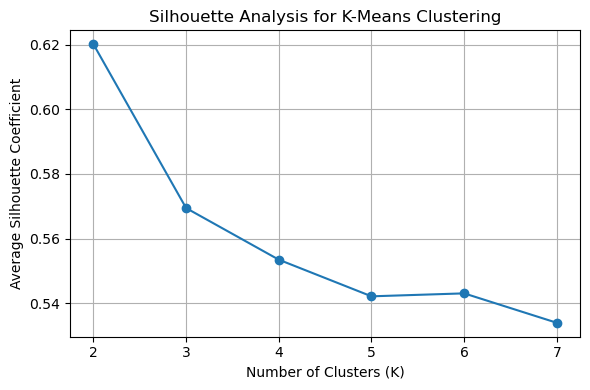

In [9]:
# Step 6: Final K-Means clustering

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(Feature_scaled)

Data["cluster"] = cluster_labels
Target = Data["cluster"].astype(int)

print(Data["cluster"].value_counts().sort_index())

ks = sorted(sil_scores.keys())
vals = [sil_scores[k] for k in ks]

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(ks, vals, marker="o")
ax.set_xlabel("Number of Clusters (K)")
ax.set_ylabel("Average Silhouette Coefficient")
ax.set_title("Silhouette Analysis for K-Means Clustering")
ax.grid(True)

fig.tight_layout()
plt.show()

Calinski-Harabasz Index (K=2): 27218.53
{2: 27218.532672799814, 3: 29692.905036524346, 4: 32115.860036352955, 5: 34065.47748926692, 6: 39072.90770589604, 7: 44744.32798728342, 8: 50604.79579531534, 9: 56497.17073133863, 10: 60927.80919904979}


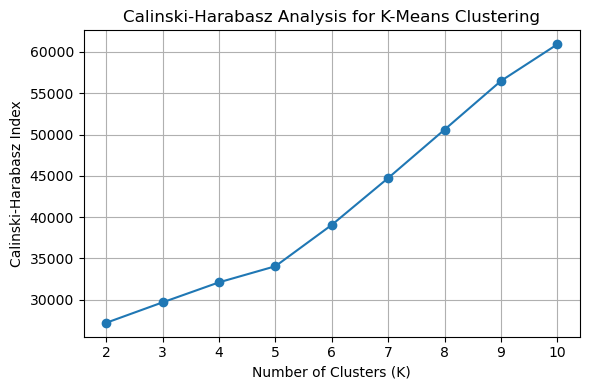

In [10]:
from sklearn.metrics import calinski_harabasz_score

ch_score = calinski_harabasz_score(Feature_scaled, cluster_labels)

print(f"Calinski-Harabasz Index (K={best_k}): {ch_score:.2f}")

ch_scores = {}

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(Feature_scaled)

    ch_scores[k] = calinski_harabasz_score(Feature_scaled, labels)

print(ch_scores)

ks = sorted(ch_scores.keys())
vals = [ch_scores[k] for k in ks]

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(ks, vals, marker="o")
ax.set_xlabel("Number of Clusters (K)")
ax.set_ylabel("Calinski-Harabasz Index")
ax.set_title("Calinski-Harabasz Analysis for K-Means Clustering")
ax.grid(True)

fig.tight_layout()
plt.show()

Davies-Bouldin Index (K=2): 0.5827
{2: 0.5827331929821971, 3: 0.5661562986282259, 4: 0.5605430317182034, 5: 0.563171636252138, 6: 0.5167237363575911, 7: 0.5245474497479293, 8: 0.5175305463739979, 9: 0.5154195837003666, 10: 0.5140455142433605}


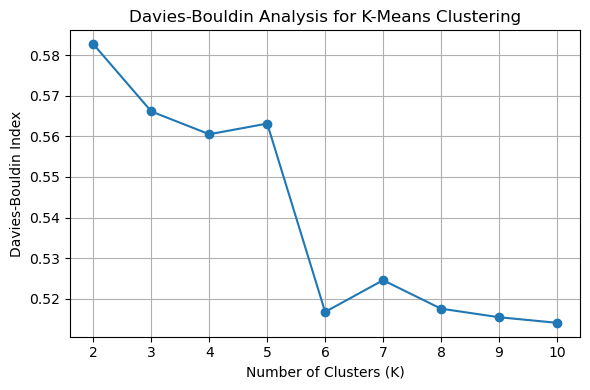

In [11]:
from sklearn.metrics import davies_bouldin_score

db_score = davies_bouldin_score(Feature_scaled, cluster_labels)

print(f"Davies-Bouldin Index (K={best_k}): {db_score:.4f}")

db_scores = {}

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(Feature_scaled)

    db_scores[k] = davies_bouldin_score(Feature_scaled, labels)

print(db_scores)

ks = sorted(db_scores.keys())
vals = [db_scores[k] for k in ks]

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(ks, vals, marker="o")
ax.set_xlabel("Number of Clusters (K)")
ax.set_ylabel("Davies-Bouldin Index")
ax.set_title("Davies-Bouldin Analysis for K-Means Clustering")
ax.grid(True)

fig.tight_layout()
plt.show()

In [12]:
print(Feature.columns.tolist())

['KWH']


In [13]:
print(Feature.columns)

Index(['KWH'], dtype='object')


In [14]:
print("Silhouette-optimal K:", max(sil_scores, key=sil_scores.get))

# Final choice based on interpretability
best_k = 4

print("Final K selected for segmentation:", best_k)

Silhouette-optimal K: 2
Final K selected for segmentation: 4


In [15]:
kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(Feature_scaled)

Data["cluster"] = cluster_labels

cluster_order = (
    Data.groupby("cluster")["KWH"]
    .mean()
    .sort_values()
    .index
)

label_map = {
    old_label: new_label
    for new_label, old_label in enumerate(cluster_order)
}

Data["cluster"] = Data["cluster"].map(label_map)

cluster_profile = Data.groupby("cluster")["KWH"].agg(
    ["count", "mean", "median", "std"]
)

print(cluster_profile)

         count          mean    median           std
cluster                                             
0         7991   5301.344436   5472.94   1894.806574
1         6750  11409.086761  11176.46   1989.386984
2         3149  19395.812956  18778.77   2923.561256
3          606  33346.463779  30666.60  10626.896708


In [16]:
cluster_summary = Data.groupby("cluster")[features].mean().round(2)
cluster_counts = Data["cluster"].value_counts().sort_index()
cluster_summary["Households"] = cluster_counts.values

cols = ["Households"] + [c for c in cluster_summary.columns if c != "Households"]
cluster_summary = cluster_summary[cols]

key_cols = ["Households", "TOTSQFT_EN", "MONEYPY", "KWH", "YEARMADERANGE"]
display(cluster_summary[key_cols])

,Households,TOTSQFT_EN,MONEYPY,KWH,YEARMADERANGE
cluster,,,,,
0,7991,1553.54,10.82,5301.34,4.20
1,6750,2092.32,12.06,11409.09,4.70
2,3149,2443.72,12.51,19395.81,4.97
3,606,3331.37,13.29,33346.46,5.02


ANOVA Results
-------------
F-statistic: 18681.3555
p-value: 0.000000e+00

Tukey HSD Results
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj lower  upper  reject
-------------------------------------------------
     0      1   0.8384   0.0 0.8243 0.8525   True
     0      2   1.3732   0.0 1.3552 1.3911   True
     0      3    1.898   0.0 1.8621 1.9339   True
     1      2   0.5348   0.0 0.5164 0.5531   True
     1      3   1.0596   0.0 1.0234 1.0957   True
     2      3   0.5248   0.0  0.487 0.5626   True
-------------------------------------------------


<Figure size 800x500 with 0 Axes>

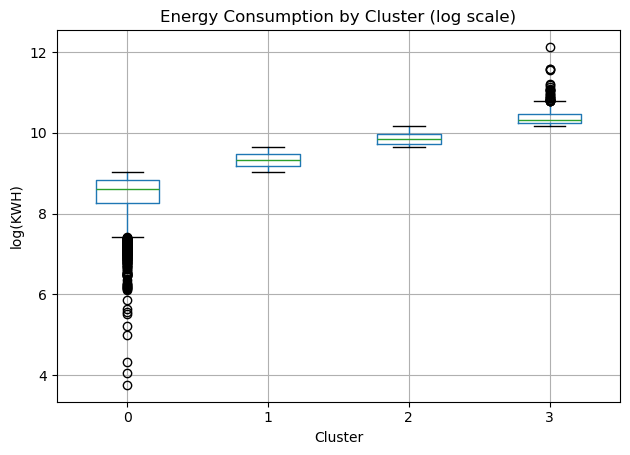

In [17]:
# Step 9: Statistical Validation of Clusters (ANOVA + Tukey HSD)

Data['log_KWH'] = np.log1p(Data['KWH'])

groups = [
    Data.loc[Data['cluster'] == c, 'log_KWH']
    for c in sorted(Data['cluster'].unique())
]

f_stat, p_value = f_oneway(*groups)

print("ANOVA Results")
print("-------------")
print(f"F-statistic: {f_stat:.4f}")
print(f"p-value: {p_value:.6e}")

tukey = pairwise_tukeyhsd(
    endog=Data['log_KWH'],
    groups=Data['cluster'],
    alpha=0.05
)

print("\nTukey HSD Results")
print(tukey)

plt.figure(figsize=(8, 5))
Data.boxplot(column='log_KWH', by='cluster')
plt.title("Energy Consumption by Cluster (log scale)")
plt.suptitle("")
plt.xlabel("Cluster")
plt.ylabel("log(KWH)")
plt.tight_layout()
plt.show()

Using predictors: ['TOTSQFT_EN', 'HHAGE']
Regression data shape: (18496, 3)
                            OLS Regression Results                            
Dep. Variable:                log_KWH   R-squared:                       0.150
Model:                            OLS   Adj. R-squared:                  0.150
Method:                 Least Squares   F-statistic:                     1631.
Date:                Sat, 13 Jun 2026   Prob (F-statistic):               0.00
Time:                        21:40:16   Log-Likelihood:                -17217.
No. Observations:               18496   AIC:                         3.444e+04
Df Residuals:                   18493   BIC:                         3.446e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------

,Variable,VIF
0,const,12.617
1,TOTSQFT_EN,1.020
2,HHAGE,1.020


,Variable,Coefficient,P_value
0,const,8.7729,0.0
1,TOTSQFT_EN,0.0002,0.0
2,HHAGE,-0.0022,0.0


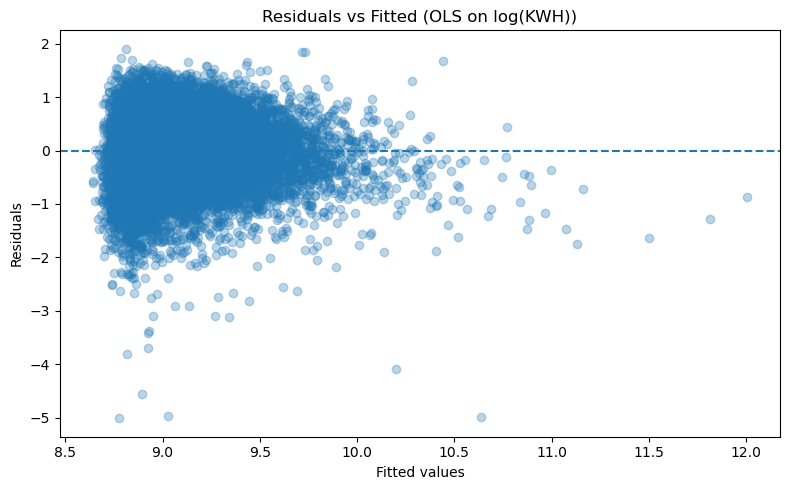

In [18]:
if "KWH" not in Data.columns:
    raise ValueError("KWH column not found in Data")

Data["log_KWH"] = np.log1p(Data["KWH"])

candidate_predictors = ["TOTSQFT_EN", "NHSLDMEM", "HDD65", "CDD65", "HHAGE"]
predictors = [c for c in candidate_predictors if c in Data.columns]

if len(predictors) < 2:
    raise ValueError(f"Not enough predictors found. Found: {predictors}")

print("Using predictors:", predictors)

df_reg = Data[predictors + ["log_KWH"]].dropna()

X = sm.add_constant(df_reg[predictors])   # add intercept
y = df_reg["log_KWH"]

print("Regression data shape:", X.shape)

ols_model = sm.OLS(y, X).fit()
print(ols_model.summary())

vif_df = pd.DataFrame({
    "Variable": X.columns,
    "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})

display(vif_df.round(3))

coef_table = pd.DataFrame({
    "Variable": ols_model.params.index,
    "Coefficient": ols_model.params.values,
    "P_value": ols_model.pvalues.values
}).sort_values("P_value")

display(coef_table.round(4))

plt.figure(figsize=(8, 5))
plt.scatter(ols_model.fittedvalues, ols_model.resid, alpha=0.3)
plt.axhline(0, linestyle="--")
plt.title("Residuals vs Fitted (OLS on log(KWH))")
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.tight_layout()
plt.show()

PCR dataset -> X: (18496, 11) | y: (18496,)


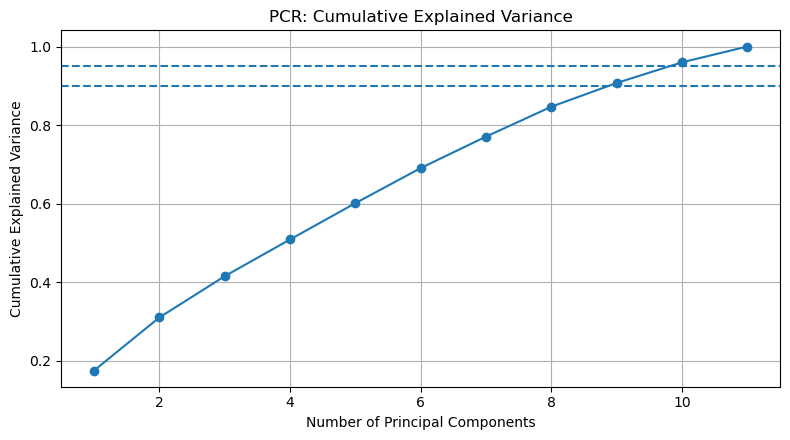

In [19]:
# Step 11: PCA-based Regression (PCR)

if "log_KWH" not in Data.columns:
    Data["log_KWH"] = np.log1p(Data["KWH"])

Data_pcr = Data.copy()
cat_cols = [c for c in ["REGIONC", "TYPEHUQ"] if c in Data_pcr.columns]
Data_pcr = pd.get_dummies(Data_pcr, columns=cat_cols, drop_first=True, dummy_na=True)

drop_cols = [c for c in ["KWH", "log_KWH", "cluster"] if c in Data_pcr.columns]
X_full = Data_pcr.drop(columns=drop_cols, errors="ignore").select_dtypes(include=[np.number]).copy()
y_full = Data_pcr["log_KWH"].copy()


reg_df = pd.concat([X_full, y_full], axis=1).dropna()
X_full = reg_df.drop(columns=["log_KWH"])
y_full = reg_df["log_KWH"]

print("PCR dataset -> X:", X_full.shape, "| y:", y_full.shape)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_full)

pca_all = PCA()
X_pca_all = pca_all.fit_transform(X_scaled)
explained = np.cumsum(pca_all.explained_variance_ratio_)

plt.figure(figsize=(8,4.5))
plt.plot(np.arange(1, len(explained)+1), explained, marker="o")
plt.axhline(0.90, linestyle="--")
plt.axhline(0.95, linestyle="--")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCR: Cumulative Explained Variance")
plt.grid(True)
plt.tight_layout()
plt.show()

Selected number of PCs to reach ~95% variance: m = 10
PC matrix -> Train: (14796, 10) | Test: (3700, 10)

 PCR SUMMARY 

                            OLS Regression Results                            
Dep. Variable:                log_KWH   R-squared:                       0.167
Model:                            OLS   Adj. R-squared:                  0.167
Method:                 Least Squares   F-statistic:                     297.0
Date:                Sat, 13 Jun 2026   Prob (F-statistic):               0.00
Time:                        21:40:17   Log-Likelihood:                -13733.
No. Observations:               14796   AIC:                         2.749e+04
Df Residuals:                   14785   BIC:                         2.757e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
----------

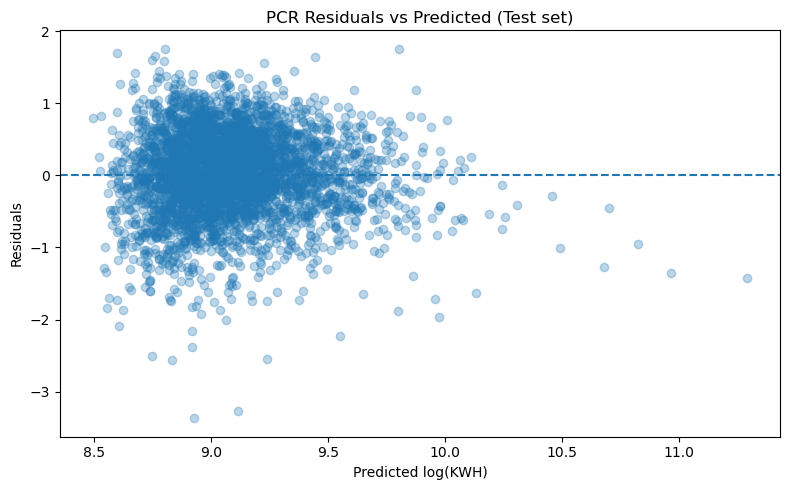


PCR Performance Metrics:


,n_PCs,R2_test,MAE_test,RMSE_test
0,10,0.168,0.4618,0.588


In [20]:
m = int(np.argmax(explained >= 0.95) + 1)
print(f"Selected number of PCs to reach ~95% variance: m = {m}")

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_full, test_size=0.2, random_state=42
)

pca = PCA(n_components=m)
X_train_pcs = pca.fit_transform(X_train)
X_test_pcs = pca.transform(X_test)

print("PC matrix -> Train:", X_train_pcs.shape, "| Test:", X_test_pcs.shape)

X_train_pcs_sm = sm.add_constant(X_train_pcs)
X_test_pcs_sm = sm.add_constant(X_test_pcs)

pcr_model = sm.OLS(y_train, X_train_pcs_sm).fit()

print("\n PCR SUMMARY \n")
print(pcr_model.summary())

pred_test = pcr_model.predict(X_test_pcs_sm)

r2 = r2_score(y_test, pred_test)
mae = mean_absolute_error(y_test, pred_test)
rmse = np.sqrt(mean_squared_error(y_test, pred_test))

print("\n PCR TEST METRICS \n")
print(f"PCR Test R²  : {r2:.3f}")
print(f"PCR Test MAE : {mae:.3f}")
print(f"PCR Test RMSE: {rmse:.3f}")

residuals = y_test - pred_test

plt.figure(figsize=(8,5))
plt.scatter(pred_test, residuals, alpha=0.3)
plt.axhline(0, linestyle="--")
plt.title("PCR Residuals vs Predicted (Test set)")
plt.xlabel("Predicted log(KWH)")
plt.ylabel("Residuals")
plt.tight_layout()
plt.show()

pcr_metrics = pd.DataFrame([{
    "n_PCs": m,
    "R2_test": r2,
    "MAE_test": mae,
    "RMSE_test": rmse
}])

from IPython.display import display

print("\nPCR Performance Metrics:")
display(pcr_metrics.round(4))

In [21]:
# Step 12 : Clustering Variants Comparison 

if "X_pca" not in globals():
    from sklearn.preprocessing import StandardScaler
    from sklearn.decomposition import PCA

    features = Data.select_dtypes(include=[np.number]).drop(
        columns=["KWH", "log_KWH", "cluster"], errors="ignore"
    ).dropna()

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(features)

    pca = PCA(n_components=6)
    X_pca = pca.fit_transform(X_scaled)

print("PCA feature shape used for clustering:", X_pca.shape)

K = Data["cluster"].nunique()
print("Number of clusters (K):", K)

results = []

kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
labels_km = kmeans.fit_predict(X_pca)

results.append({
    "Method": "K-Means",
    "Silhouette": silhouette_score(X_pca, labels_km),
    "Calinski_Harabasz": calinski_harabasz_score(X_pca, labels_km),
    "Davies_Bouldin": davies_bouldin_score(X_pca, labels_km)
})

agg = AgglomerativeClustering(n_clusters=K, linkage="ward")
labels_agg = agg.fit_predict(X_pca)

results.append({
    "Method": "Agglomerative",
    "Silhouette": silhouette_score(X_pca, labels_agg),
    "Calinski_Harabasz": calinski_harabasz_score(X_pca, labels_agg),
    "Davies_Bouldin": davies_bouldin_score(X_pca, labels_agg)
})

gmm = GaussianMixture(n_components=K, random_state=42)
labels_gmm = gmm.fit_predict(X_pca)

results.append({
    "Method": "GMM",
    "Silhouette": silhouette_score(X_pca, labels_gmm),
    "Calinski_Harabasz": calinski_harabasz_score(X_pca, labels_gmm),
    "Davies_Bouldin": davies_bouldin_score(X_pca, labels_gmm)
})

results_df = pd.DataFrame(results)
print("\nClustering Comparison Results:\n")
print(results_df)

display(results_df)

PCA feature shape used for clustering: (18496, 6)
Number of clusters (K): 4

Clustering Comparison Results:

          Method  Silhouette  Calinski_Harabasz  Davies_Bouldin
0        K-Means    0.197482        3895.075145        1.351187
1  Agglomerative    0.187929        3587.018375        1.414700
2            GMM    0.191401        3696.221109        1.398781


,Method,Silhouette,Calinski_Harabasz,Davies_Bouldin
0,K-Means,0.197482,3895.075145,1.351187
1,Agglomerative,0.187929,3587.018375,1.414700
2,GMM,0.191401,3696.221109,1.398781


In [22]:
# Target
Target = Data["cluster"].astype(int)

# Household predictors only
Predictors = Data[
    [
        "TYPEHUQ",
        "YEARMADERANGE",
        "TOTSQFT_EN",
        "WALLTYPE",
        "ROOFTYPE",
        "ADQINSUL",
        "HHSEX",
        "HHAGE",
        "EMPLOYHH",
        "MONEYPY"
    ]
].copy()

# Impute missing values
Predictors["TOTSQFT_EN"] = Predictors["TOTSQFT_EN"].fillna(Predictors["TOTSQFT_EN"].median())
Predictors["HHAGE"] = Predictors["HHAGE"].fillna(Predictors["HHAGE"].median())

cat_cols = [
    "TYPEHUQ",
    "YEARMADERANGE",
    "WALLTYPE",
    "ROOFTYPE",
    "ADQINSUL",
    "HHSEX",
    "EMPLOYHH",
    "MONEYPY"
]

for col in cat_cols:
    Predictors[col] = Predictors[col].fillna(Predictors[col].mode()[0]).astype(str)

# One-hot encode categorical variables
Feature_full = pd.get_dummies(
    Predictors,
    columns=cat_cols,
    drop_first=False
)

# Train-test split
Feature_train, Feature_test, Target_train, Target_test = train_test_split(
    Feature_full,
    Target,
    test_size=0.3,
    random_state=42,
    stratify=Target
)

# Random Forest
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)

rf.fit(Feature_train, Target_train)

Target_pred = rf.predict(Feature_test)

print(classification_report(Target_test, Target_pred, zero_division=0))

              precision    recall  f1-score   support

           0       0.58      0.66      0.62      2397
           1       0.41      0.47      0.44      2025
           2       0.32      0.16      0.21       945
           3       0.16      0.04      0.06       182

    accuracy                           0.48      5549
   macro avg       0.37      0.33      0.33      5549
weighted avg       0.46      0.48      0.47      5549



In [23]:
# Step 13b: Compare multiple classifiers for predicting clusters

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        multi_class="multinomial",
        n_jobs=-1
    ),
    "SVM": SVC(
        kernel="rbf",
        probability=True
    ),
    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42
    ),
    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="multi:softmax",
        eval_metric="mlogloss",
        random_state=42
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="multiclass"
    )
}

results = []

for name, model in models.items():
    if name in ["Logistic Regression", "SVM"]:
        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("clf", model)
        ])
    else:
        pipe = Pipeline([
            ("clf", model)
        ])
    
    print("=" * 70)
    print(f"Training model: {name}")
    
    pipe.fit(Feature_train, Target_train)
    preds = pipe.predict(Feature_test)
    
    acc = accuracy_score(Target_test, preds)
    f1_macro = f1_score(Target_test, preds, average="macro")
    
    print(f"Test Accuracy:  {acc:.4f}")
    print(f"Test F1-macro:  {f1_macro:.4f}")
    print("\nClassification report:\n")
    print(classification_report(Target_test, preds))
    
    results.append({
        "Model": name,
        "Test Accuracy": acc,
        "Test F1_macro": f1_macro
    })

results_df = pd.DataFrame(results).sort_values("Test F1_macro", ascending=False)
display(results_df)

Training model: Logistic Regression


F:\Users\saipr\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Test Accuracy:  0.5230
Test F1-macro:  0.3455

Classification report:

              precision    recall  f1-score   support

           0       0.63      0.68      0.65      2397
           1       0.43      0.58      0.50      2025
           2       0.42      0.09      0.15       945
           3       0.29      0.05      0.08       182

    accuracy                           0.52      5549
   macro avg       0.44      0.35      0.35      5549
weighted avg       0.51      0.52      0.49      5549

Training model: SVM
Test Accuracy:  0.5118
Test F1-macro:  0.3130

Classification report:

              precision    recall  f1-score   support

           0       0.62      0.65      0.63      2397
           1       0.42      0.60      0.50      2025
           2       0.44      0.07      0.12       945
           3       0.00      0.00      0.00       182

    accuracy                           0.51      5549
   macro avg       0.37      0.33      0.31      5549
weighted avg       0.50

,Model,Test Accuracy,Test F1_macro
5,LightGBM,0.504956,0.353780
0,Logistic Regression,0.522977,0.345542
4,XGBoost,0.514327,0.338305
3,Random Forest,0.489818,0.337173
2,Decision Tree,0.422959,0.323058
1,SVM,0.511804,0.313006


In [24]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", models["Logistic Regression"])
])

cv_acc = cross_val_score(lr_pipe, Feature_full, Target, cv=skf, scoring="accuracy")
cv_f1 = cross_val_score(lr_pipe, Feature_full, Target, cv=skf, scoring="f1_macro")

print(f"Logistic Regression 5-fold CV Accuracy:  mean={cv_acc.mean():.4f}, std={cv_acc.std():.4f}")
print(f"Logistic Regression 5-fold CV Macro F1:  mean={cv_f1.mean():.4f}, std={cv_f1.std():.4f}")

F:\Users\saipr\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
F:\Users\saipr\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
F:\Users\saipr\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
F:\Users\saipr\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in versio

Logistic Regression 5-fold CV Accuracy:  mean=0.5256, std=0.0100
Logistic Regression 5-fold CV Macro F1:  mean=0.3522, std=0.0184


In [25]:
# Step 13: Predict cluster membership using household attributes only

# Target: KWH-based cluster labels
Target = Data["cluster"].astype(int)

# Predictors: household/demographic/structural variables only
Predictors = Data[
    [
        "TYPEHUQ",
        "YEARMADERANGE",
        "TOTSQFT_EN",
        "WALLTYPE",
        "ROOFTYPE",
        "ADQINSUL",
        "HHSEX",
        "HHAGE",
        "EMPLOYHH",
        "MONEYPY"
    ]
].copy()

# Define feature types
numeric_features = [
    "TOTSQFT_EN",
    "HHAGE"
]

categorical_features = [
    "TYPEHUQ",
    "YEARMADERANGE",
    "WALLTYPE",
    "ROOFTYPE",
    "ADQINSUL",
    "HHSEX",
    "EMPLOYHH",
    "MONEYPY"
]

# Preprocessing for household predictors
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            numeric_features
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]),
            categorical_features
        )
    ]
)

# Train/test split
Predictors_train, Predictors_test, Target_train, Target_test = train_test_split(
    Predictors,
    Target,
    test_size=0.3,
    random_state=42,
    stratify=Target
)

In [26]:
# Step 13b: Compare multiple classifiers

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        multi_class="multinomial",
        class_weight="balanced",
        n_jobs=-1
    ),

    "SVM": SVC(
        kernel="rbf",
        probability=True,
        class_weight="balanced"
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced"
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced"
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="multi:softprob",
        eval_metric="mlogloss",
        random_state=42
    ),

    "LightGBM": LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="multiclass",
        class_weight="balanced",
        random_state=42
    )
}

results = []

for name, model in models.items():

    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("clf", model)
    ])

    print("=" * 70)
    print(f"Training model: {name}")

    pipe.fit(Predictors_train, Target_train)
    preds = pipe.predict(Predictors_test)

    acc = accuracy_score(Target_test, preds)
    bal_acc = balanced_accuracy_score(Target_test, preds)
    macro_prec = precision_score(Target_test, preds, average="macro", zero_division=0)
    macro_rec = recall_score(Target_test, preds, average="macro", zero_division=0)
    f1_macro = f1_score(Target_test, preds, average="macro")
    mcc = matthews_corrcoef(Target_test, preds)

    print(f"Test Accuracy:         {acc:.4f}")
    print(f"Balanced Accuracy:     {bal_acc:.4f}")
    print(f"Macro Precision:       {macro_prec:.4f}")
    print(f"Macro Recall:          {macro_rec:.4f}")
    print(f"Macro F1-score:        {f1_macro:.4f}")
    print(f"Matthews Corr. Coeff.: {mcc:.4f}")
    print("\nClassification report:\n")
    print(classification_report(Target_test, preds, zero_division=0))

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Balanced Accuracy": bal_acc,
        "Macro Precision": macro_prec,
        "Macro Recall": macro_rec,
        "Macro F1": f1_macro,
        "MCC": mcc
    })

results_df = pd.DataFrame(results).sort_values("Macro F1", ascending=False)
display(results_df)

Training model: Logistic Regression


F:\Users\saipr\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Test Accuracy:         0.4152
Balanced Accuracy:     0.4301
Macro Precision:       0.3642
Macro Recall:          0.4301
Macro F1-score:        0.3482
Matthews Corr. Coeff.: 0.1933

Classification report:

              precision    recall  f1-score   support

           0       0.67      0.56      0.61      2397
           1       0.44      0.26      0.33      2025
           2       0.25      0.34      0.29       945
           3       0.10      0.55      0.17       182

    accuracy                           0.42      5549
   macro avg       0.36      0.43      0.35      5549
weighted avg       0.50      0.42      0.44      5549

Training model: SVM
Test Accuracy:         0.4208
Balanced Accuracy:     0.4000
Macro Precision:       0.3600
Macro Recall:          0.4000
Macro F1-score:        0.3506
Matthews Corr. Coeff.: 0.1838

Classification report:

              precision    recall  f1-score   support

           0       0.68      0.54      0.60      2397
           1       0.42   

F:\Users\saipr\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Test Accuracy:         0.4495
Balanced Accuracy:     0.3945
Macro Precision:       0.3644
Macro Recall:          0.3945
Macro F1-score:        0.3662
Matthews Corr. Coeff.: 0.1968

Classification report:

              precision    recall  f1-score   support

           0       0.66      0.58      0.62      2397
           1       0.43      0.35      0.38      2025
           2       0.26      0.36      0.30       945
           3       0.11      0.29      0.16       182

    accuracy                           0.45      5549
   macro avg       0.36      0.39      0.37      5549
weighted avg       0.49      0.45      0.46      5549



,Model,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1,MCC
5,LightGBM,0.449450,0.394481,0.364379,0.394481,0.366198,0.196809
1,SVM,0.420797,0.399981,0.360000,0.399981,0.350598,0.183771
0,Logistic Regression,0.415210,0.430060,0.364200,0.430060,0.348245,0.193292
4,XGBoost,0.513606,0.343833,0.397107,0.343833,0.339678,0.216510
3,Random Forest,0.485493,0.332518,0.366624,0.332518,0.333614,0.174987
2,Decision Tree,0.411966,0.316555,0.312635,0.316555,0.313971,0.105948


In [27]:
# Step 13c: 5-fold cross-validation for Logistic Regression

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("clf", models["Logistic Regression"])
])

cv_acc = cross_val_score(
    lr_pipe,
    Predictors,
    Target,
    cv=skf,
    scoring="accuracy"
)

cv_f1 = cross_val_score(
    lr_pipe,
    Predictors,
    Target,
    cv=skf,
    scoring="f1_macro"
)

print(f"Logistic Regression 5-fold CV Accuracy: mean={cv_acc.mean():.4f}, std={cv_acc.std():.4f}")
print(f"Logistic Regression 5-fold CV Macro F1: mean={cv_f1.mean():.4f}, std={cv_f1.std():.4f}")


F:\Users\saipr\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
F:\Users\saipr\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
F:\Users\saipr\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
F:\Users\saipr\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in versio

Logistic Regression 5-fold CV Accuracy: mean=0.4261, std=0.0050
Logistic Regression 5-fold CV Macro F1: mean=0.3542, std=0.0047


len(importances) = 58
len(feature_names) = 58
Top 20 features
            Feature  Importance
0        TOTSQFT_EN    0.209532
1             HHAGE    0.163863
33       ADQINSUL_2    0.023710
37          HHSEX_2    0.021718
36          HHSEX_1    0.021461
18       WALLTYPE_3    0.020778
32       ADQINSUL_1    0.020723
49       MONEYPY_16    0.019416
3         TYPEHUQ_2    0.018078
10  YEARMADERANGE_4    0.017803
38       EMPLOYHH_1    0.017627
12  YEARMADERANGE_6    0.017408
16       WALLTYPE_1    0.016953
17       WALLTYPE_2    0.016843
48       MONEYPY_15    0.016792
11  YEARMADERANGE_5    0.016773
29       ROOFTYPE_5    0.016685
13  YEARMADERANGE_7    0.016353
34       ADQINSUL_3    0.015967
47       MONEYPY_14    0.015574


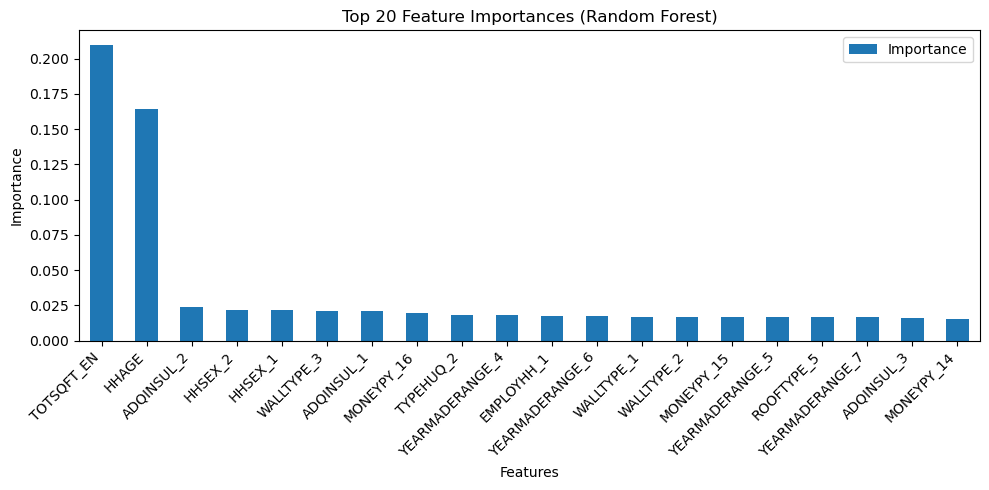

In [29]:
# Get feature names directly from Feature_full
feature_names = Feature_full.columns

# Random Forest importances
importances = rf.feature_importances_

print("len(importances) =", len(importances))
print("len(feature_names) =", len(feature_names))

feat_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

print("Top 20 features")
print(feat_importance.head(20))

feat_importance.head(20).plot(
    x="Feature",
    y="Importance",
    kind="bar",
    figsize=(10,5)
)

plt.title("Top 20 Feature Importances (Random Forest)")
plt.ylabel("Importance")
plt.xlabel("Features")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [30]:
importance_grouped = feat_importance.copy()

importance_grouped["BaseFeature"] = (
    importance_grouped["Feature"]
    .str.split("_")
    .str[0]
)

grouped_importance = (
    importance_grouped
    .groupby("BaseFeature")["Importance"]
    .sum()
    .sort_values(ascending=False)
)

print("\nAggregated feature importance:")
print(grouped_importance)


Aggregated feature importance:
BaseFeature
TOTSQFT          0.209532
HHAGE            0.163863
MONEYPY          0.149032
YEARMADERANGE    0.123636
WALLTYPE         0.081108
ADQINSUL         0.064057
ROOFTYPE         0.061048
EMPLOYHH         0.054949
TYPEHUQ          0.049595
HHSEX            0.043179
Name: Importance, dtype: float64


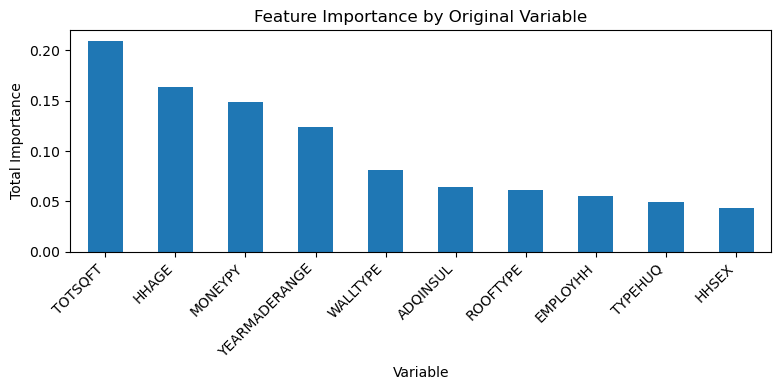

In [31]:
grouped_importance.head(10).plot(
    kind="bar",
    figsize=(8,4)
)

plt.title("Feature Importance by Original Variable")
plt.ylabel("Total Importance")
plt.xlabel("Variable")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [32]:
# Unweighted Gini

def gini(x):
    x = np.asarray(x, dtype=float)

    if np.amin(x) < 0:
        x = x - np.amin(x)

    x = x + 1e-9
    x = np.sort(x)

    n = len(x)
    index = np.arange(1, n + 1)

    return ((2 * np.sum(index * x)) / (n * np.sum(x))) - ((n + 1) / n)

overall_gini = gini(Data["KWH"])
print("Overall Gini:", overall_gini)

cluster_gini = (
    Data.groupby("cluster")["KWH"]
    .apply(gini)
)

print(cluster_gini)

Overall Gini: 0.33548847879514887
cluster
0    0.204635
1    0.100060
2    0.085108
3    0.116794
Name: KWH, dtype: float64


In [33]:
# Weighted Gini

def weighted_gini(values, weights):

    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)

    sorter = np.argsort(values)

    values = values[sorter]
    weights = weights[sorter]

    cumw = np.cumsum(weights)
    cumxw = np.cumsum(values * weights)

    cumw = cumw / cumw[-1]
    cumxw = cumxw / cumxw[-1]

    B = np.trapz(cumxw, cumw)

    return 1 - 2 * B

weighted_overall_gini = weighted_gini(
    Data["KWH"],
    Data["NWEIGHT"]
)

print("Weighted Gini:", weighted_overall_gini)

weighted_cluster_gini = Data.groupby("cluster").apply(
    lambda df: weighted_gini(
        df["KWH"],
        df["NWEIGHT"]
    )
)

print(weighted_cluster_gini)

Weighted Gini: 0.34326964674105964
cluster
0    0.214889
1    0.100261
2    0.085489
3    0.109867
dtype: float64


C:\Users\saipr\AppData\Local\Temp\ipykernel_28888\1950716156.py:19: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  B = np.trapz(cumxw, cumw)
C:\Users\saipr\AppData\Local\Temp\ipykernel_28888\1950716156.py:30: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  weighted_cluster_gini = Data.groupby("cluster").apply(


In [34]:
# comparision 

gini_results = pd.DataFrame({
    "Unweighted_Gini": cluster_gini,
    "Weighted_Gini": weighted_cluster_gini
})

print(gini_results)

         Unweighted_Gini  Weighted_Gini
cluster                                
0               0.204635       0.214889
1               0.100060       0.100261
2               0.085108       0.085489
3               0.116794       0.109867


In [36]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    matthews_corrcoef,
    roc_auc_score,
    classification_report
)

results = []

for name, model in models.items():

    print("=" * 70)
    print(f"Training model: {name}")

    model.fit(Feature_train, Target_train)

    preds = model.predict(Feature_test)

    acc = accuracy_score(Target_test, preds)
    macro_prec = precision_score(Target_test, preds, average="macro", zero_division=0)
    macro_rec = recall_score(Target_test, preds, average="macro", zero_division=0)
    f1_macro = f1_score(Target_test, preds, average="macro")
    bal_acc = balanced_accuracy_score(Target_test, preds)
    mcc = matthews_corrcoef(Target_test, preds)

    # ROC-AUC requires predicted probabilities
    try:
        if hasattr(model, "predict_proba"):
            probs = model.predict_proba(Feature_test)
            roc_auc = roc_auc_score(
                Target_test,
                probs,
                multi_class="ovr",
                average="macro"
            )
        else:
            roc_auc = np.nan
    except Exception:
        roc_auc = np.nan

    print(f"Accuracy:       {acc:.4f}")
    print(f"Macro-P:        {macro_prec:.4f}")
    print(f"Macro-R:        {macro_rec:.4f}")
    print(f"Macro-F1:       {f1_macro:.4f}")
    print(f"Balanced acc.:  {bal_acc:.4f}")
    print(f"MCC:            {mcc:.4f}")
    print(f"ROC-AUC:        {roc_auc:.4f}")
    print("\nClassification report:\n")
    print(classification_report(Target_test, preds, zero_division=0))

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Macro-P": macro_prec,
        "Macro-R": macro_rec,
        "Macro-F1": f1_macro,
        "Bal. acc.": bal_acc,
        "MCC": mcc,
        "ROC-AUC": roc_auc
    })

results_df = pd.DataFrame(results).sort_values("Macro-F1", ascending=False)

display(results_df)

Training model: Logistic Regression


F:\Users\saipr\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Accuracy:       0.4212
Macro-P:        0.3680
Macro-R:        0.4352
Macro-F1:       0.3535
Balanced acc.:  0.4352
MCC:            0.1990
ROC-AUC:        0.6972

Classification report:

              precision    recall  f1-score   support

           0       0.67      0.57      0.61      2397
           1       0.45      0.27      0.33      2025
           2       0.26      0.35      0.30       945
           3       0.10      0.55      0.17       182

    accuracy                           0.42      5549
   macro avg       0.37      0.44      0.35      5549
weighted avg       0.50      0.42      0.44      5549

Training model: SVM
Accuracy:       0.3779
Macro-P:        0.3267
Macro-R:        0.3997
Macro-F1:       0.3042
Balanced acc.:  0.3997
MCC:            0.1411
ROC-AUC:        0.6712

Classification report:

              precision    recall  f1-score   support

           0       0.59      0.59      0.59      2397
           1       0.42      0.17      0.24      2025
          

,Model,Accuracy,Macro-P,Macro-R,Macro-F1,Bal. acc.,MCC,ROC-AUC
5,LightGBM,0.450532,0.366392,0.399145,0.368675,0.399145,0.198513,0.688190
0,Logistic Regression,0.421157,0.367971,0.435155,0.353487,0.435155,0.199014,0.697247
4,XGBoost,0.514327,0.393210,0.343422,0.338305,0.343422,0.217533,0.717645
3,Random Forest,0.484592,0.368221,0.331771,0.332804,0.331771,0.173254,0.688223
2,Decision Tree,0.414669,0.314368,0.318036,0.315662,0.318036,0.109898,0.548660
1,SVM,0.377906,0.326689,0.399658,0.304158,0.399658,0.141075,0.671221
